# Stock Price Predictor using Machine Learning

Initial imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf       # yahoo finance API from which we will get our data
import matplotlib.pyplot as plt     # Visualization

import torch        # Deep learning library
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler        # scale and...
from sklearn.metrics import root_mean_squared_error     # ... evaluation

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  295.391724  295.409927  293.264055  294.182418  59151200
2020-01-03  293.154999  294.273400  291.963868  292.018422  77709700
2020-01-06  294.273438  294.355268  291.291033  291.409241  55653900
2020-01-07  293.446014  294.182514  293.000457  293.709680  40496400
2020-01-08  295.009857  296.219163  293.391373  293.636864  68296000
...                ...         ...         ...         ...       ...
2026-09-14  758.995239  761.628714  756.052534  757.119891  43992400
2026-09-15  755.513916  758.466545  754.276997  758.237134  46195000
2026-09-16  752.182190  759.783310  747.743201  757.618702  59217700
2026-09-17  760.710999  761.678627  758.077584  761.259685  49652800
2026-09-18  761.690002  762.000000  757.969971  761.309998  65308100

[1687 rows x 5 columns]


<Axes: xlabel='Date'>

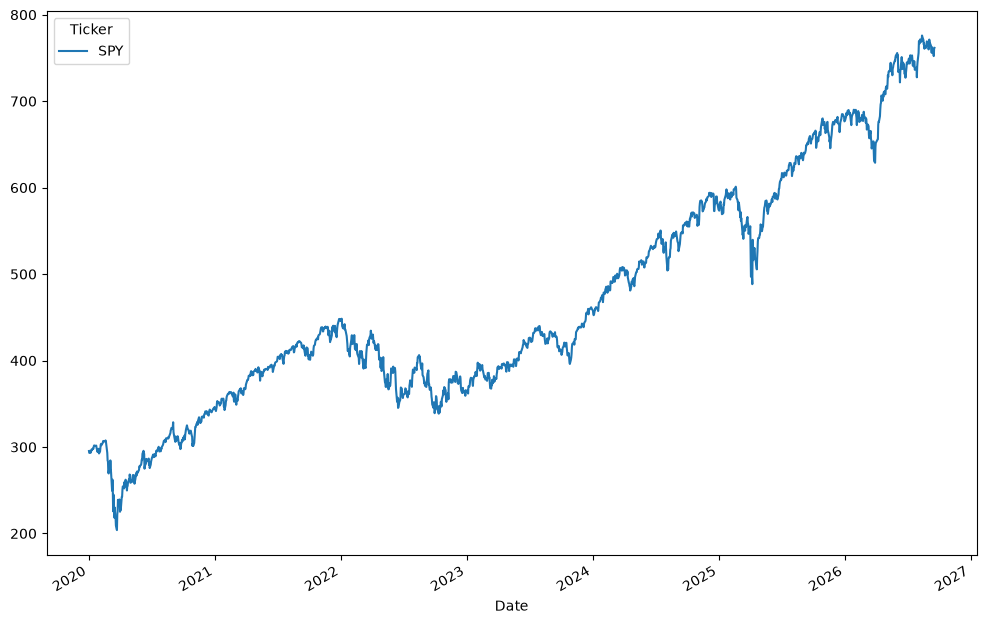

In [2]:
# Ideally, we want to use a CUDA supported GPU, but if unavailable, we can use any CPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Next we want to take our ticker, in this case SPY, and load the ticker data into a dataframe starting from january of 2020
ticker = 'SPY'
df = yf.download(ticker, '2020-01-01')
print(df)

# Plotting the Close prices of SPY
df.Close.plot(figsize=(12, 8))

We've taken our data from the yfinance import, loaded it into a dataframe and plotted the points. Our plan is to cut 80% of that data to train our model, and use it to predict or test it against the last 20% or so.

In [3]:
# We will create a scaler object to standardize our data
scaler = StandardScaler()

# Getting 80% of our data to standardize.
# Doing this will prevent look-ahead bias, prevent the model from including the test prices in our training
train_size = int(.8 * len(df))

tr_close = df[['Close']][:train_size]
ts_close = df[['Close']][train_size:]

# Scaler fits only the training data
scaler.fit(tr_close)
tr_scaled = scaler.transform(tr_close)
ts_scaled = scaler.transform(ts_close)

# Combining to one scaled series.
std_df = pd.DataFrame(np.concatenate([tr_scaled, ts_scaled]), index=df.index)
print(std_df)

                   0
Date                
2020-01-02 -1.355650
2020-01-03 -1.381267
2020-01-06 -1.368458
2020-01-07 -1.377934
2020-01-08 -1.360024
...              ...
2026-09-14  3.953980
2026-09-15  3.914109
2026-09-16  3.875951
2026-09-17  3.973631
2026-09-18  3.984843

[1687 rows x 1 columns]


We are going to scale our 

We want to show our model the previous 29 days, then have it predict the 30th day. 

In [4]:
seq_length = 30
data = []

# Looking at 29 days and predicting the last day
# The outer array (data[]) contains elements that are arrays, and each array element contains another 30 arrays
# ... corresponding to the number of days (our sequence length) 
for i in range(len(std_df) - seq_length):
    data.append(std_df[i:i+seq_length])

data = np.array(data)   # converting to a numpy array
data

array([[[-1.35565022],
        [-1.38126733],
        [-1.3684579 ],
        ...,
        [-1.24745216],
        [-1.22495798],
        [-1.22870619]],

       [[-1.38126733],
        [-1.3684579 ],
        [-1.37793434],
        ...,
        [-1.22495798],
        [-1.22870619],
        [-1.22308247]],

       [[-1.3684579 ],
        [-1.37793434],
        [-1.36002372],
        ...,
        [-1.22870619],
        [-1.22308247],
        [-1.23214264]],

       ...,

       [[ 4.0733672 ],
        [ 4.05577324],
        [ 4.04172129],
        ...,
        [ 3.99293788],
        [ 3.95398007],
        [ 3.91410863]],

       [[ 4.05577324],
        [ 4.04172129],
        [ 4.0954168 ],
        ...,
        [ 3.95398007],
        [ 3.91410863],
        [ 3.87595052]],

       [[ 4.04172129],
        [ 4.0954168 ],
        [ 4.09278913],
        ...,
        [ 3.91410863],
        [ 3.87595052],
        [ 3.97363059]]], shape=(1657, 30, 1))

Test/Train Split

We are interested in sequential prediction

In [5]:
    # training on only 80% of our data

x_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)   # up until the last index
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)    # only the last index
x_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [6]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device = device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [7]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [8]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=.01)

In [9]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(x_train)   # make a prediction

    loss = criterion(y_train_pred, y_train) # see how accurate our prediction is

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 1.0440778732299805
25 0.023309459909796715
50 0.006975333672016859
75 0.005492647644132376
100 0.005101276561617851
125 0.004836471751332283
150 0.004597972612828016
175 0.004362214356660843


In [10]:
model.eval()

y_test_pred = model(x_test)

#inverse scale
y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])
print(train_rmse)
print(test_rmse)

5.61835241317749
25.997631072998047


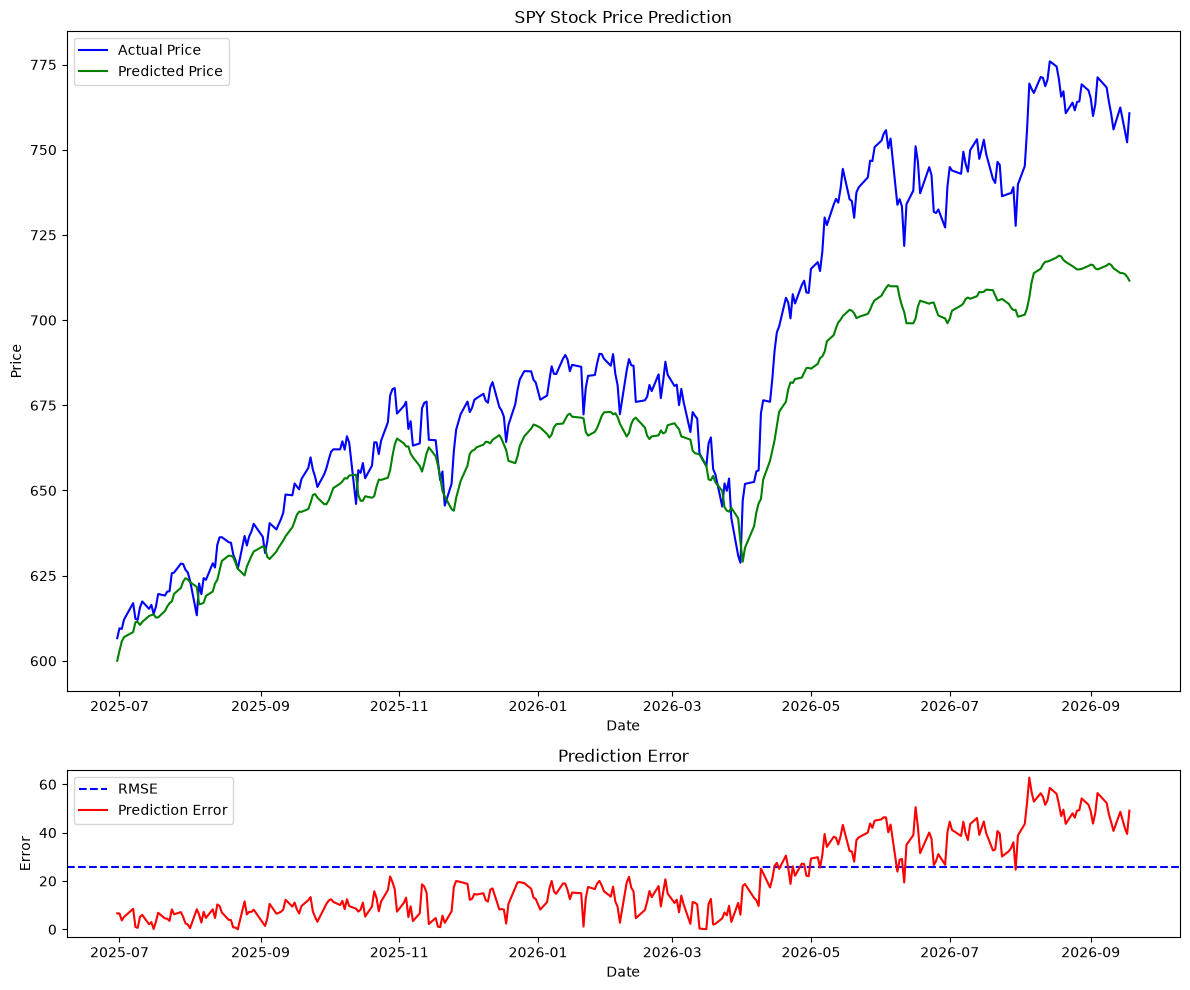

In [11]:
fig = plt.figure(figsize=(12,10))
gs = fig.add_gridspec(4,1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()

plt.show()


Prediction line lags behind, shifts to the right. Model adjust after a day has happend. After a movement the model picks up on it. RMSE shows us that as time goes on, our prediction model measures more error.